<a href="https://colab.research.google.com/github/ravi-0309/Dynamic-Response/blob/main/Multi_Degree_of_Freedom_Response.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

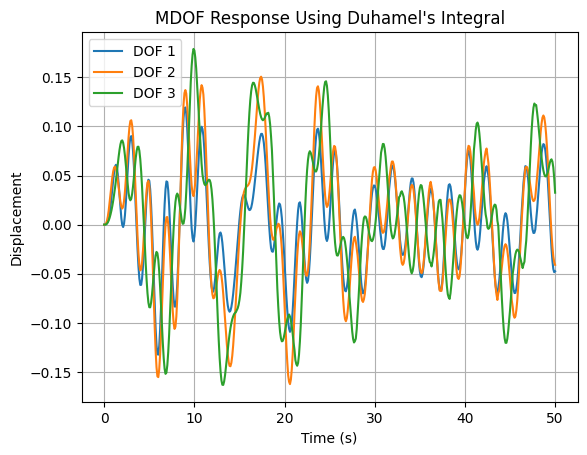

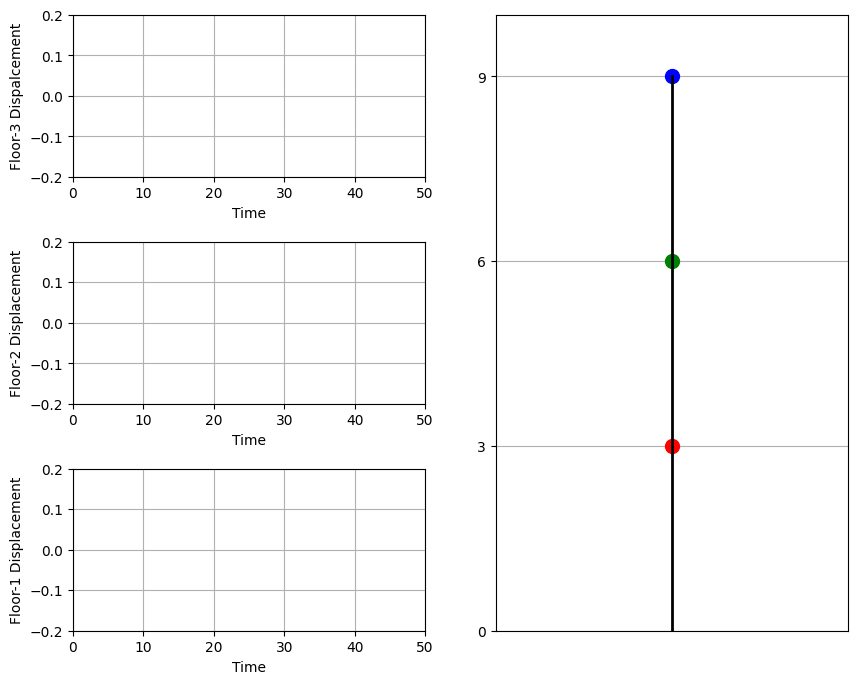

In [15]:
# MULTI DEGREE OF FREEDOM RESPONSE USING DUHAMEL'S INTEGRAL

import numpy as np
from scipy.linalg import eigh
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
import matplotlib.animation as animation
from IPython.display import HTML
import matplotlib.gridspec as gridspec

# Given Mass and Stiffness values
m1, m2, m3 = 10, 25, 50
k1, k2, k3 = 100, 150, 200

xi_1, xi_2 = 0.02, 0.02  # Damping ratios

# Mass and Stiffness matrices
M = np.diag([m1, m2, m3])
K = np.array([
    [k1 + k2, -k2, 0],
    [-k2, k2 + k3, -k3],
    [0, -k3, k3]
])

# Solve for Eigenvalues & Eigenvectors
eigenvalues, phi = eigh(K, M)
wn = np.sqrt(eigenvalues)  # Natural frequencies

# Modal Mass and Stiffness
Md = phi.T @ M @ phi
Kd = phi.T @ K @ phi

# Solve for modal damping
A = np.array([
    [1/(2*wn[0]), wn[0]/2],
    [1/(2*wn[1]), wn[1]/2]
])

xi_n = np.array([[xi_1], [xi_2]])
ab = np.linalg.inv(A) @ xi_n
C = ab[0] * M + ab[1] * K
Cd = phi.T @ C @ phi

# Modal Damping Ratio
eta_n = np.diag(Cd) / (2 * wn)

# Time and Force Definitions
time = np.arange(0, 50.1, 0.1)
F_t = np.array([
    2.5 * np.sin(1 * time),
    7.5 * np.sin(3 * time),
    2.45 * np.sin(5 * time)
])

# Compute Modal Force
F_n = phi.T @ F_t


def Duhamel_Integral(m, k, xi, t, F, time_array):
    """Computes the response using Duhamel's Integral via Trapezoidal Integration."""

    omega_n = np.sqrt(k / m)
    omega_d = omega_n * np.sqrt(1 - xi**2)

    # Avoid numerical issues for large t
    if t > time_array[-1]:
        return 0

    tau_values = np.linspace(0, t, 100)  # 100 points from 0 to t
    F_interp = np.interp(tau_values, time_array, F)  # Interpolate F(tau)

    integrand = F_interp * np.exp(-xi * omega_n * (t - tau_values)) * np.sin(omega_d * (t - tau_values))

    integral_value = trapezoid(integrand, tau_values)  # Trapezoidal Integration

    return (1 / (m * omega_d)) * integral_value


# Compute Response
Z_n = np.zeros((3, len(time)))  # Store modal responses

for i in range(3):  # Loop over modes
    for j, t in enumerate(time):
        Z_n[i, j] = Duhamel_Integral(1, wn[i]**2, eta_n[i], t, F_n[i], time)

# Transform back to physical coordinates
X_t = phi @ Z_n

# Plot the responses
plt.plot(time, X_t[0], label="DOF 1")
plt.plot(time, X_t[1], label="DOF 2")
plt.plot(time, X_t[2], label="DOF 3")
plt.xlabel("Time (s)")
plt.ylabel("Displacement")
plt.title("MDOF Response Using Duhamel's Integral")
plt.legend()
plt.grid(True)
plt.show()

# CREATING THE ANIMATION
# Generate a figure
fig = plt.figure(figsize=(10, 8), facecolor='w')

# Dividing the figure into 1x2
outer = gridspec.GridSpec(1, 2)

# Create an inner GridSpec inside the first column (left side)
inner = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=outer[0], hspace=0.4)

# Creating first subplot i.e. Top Left
ax1 = fig.add_subplot(inner[0])
curve1, = ax1.plot([], [], 'b', lw=2)
ax1.set_xlim(time[0], time[-1])
ax1.set_ylim(-0.2, 0.2)
ax1.set_xlabel('Time', fontsize=10)
ax1.set_ylabel('Floor-3 Dispalcement', fontsize=10)
ax1.grid(True)

# Creating first subplot i.e. Middle Left
ax2 = fig.add_subplot(inner[1])
curve2, = ax2.plot([], [], 'g', lw=2)
ax2.set_xlim(time[0], time[-1])
ax2.set_ylim(-0.2, 0.2)
ax2.set_xlabel('Time', fontsize=10)
ax2.set_ylabel('Floor-2 Displacement', fontsize=10)
ax2.grid(True)

# Creating first subplot i.e. Bottom Left
ax3 = fig.add_subplot(inner[2])
curve3, = ax3.plot([], [], 'r', lw=2)
ax3.set_xlim(time[0], time[-1])
ax3.set_ylim(-0.2, 0.2)
ax3.set_xlabel('Time', fontsize=10)
ax3.set_ylabel('Floor-1 Displacement', fontsize=10)
ax3.grid(True)

# Create second column subplot (Right Side)
ax4 = fig.add_subplot(outer[1])
ax4.set_xlim(-1, 1)  # Narrow X range to focus on vertical motion
ax4.set_ylim(0, 10)
ax4.set_xticks([])  # Hide X-axis ticks
ax4.set_yticks([0, 3, 6, 9])  # Hide Y-axis ticks
ax4.grid(True)

# Equilibrium positions of the masses
y_eq = [3, 6, 9]  # Initial Y positions for masses
x_pos = [0, 0, 0]  # All masses aligned at x=0

# Create mass markers
mass1, = ax4.plot(x_pos[0], y_eq[2], 'ro', markersize=10)  # Mass 1
mass2, = ax4.plot(x_pos[1], y_eq[1], 'go', markersize=10)  # Mass 2
mass3, = ax4.plot(x_pos[2], y_eq[0], 'bo', markersize=10)  # Mass 3

# Create two separate vertical lines between consecutive masses
connector1, = ax4.plot([0, 0], [0, y_eq[0]], 'k-', lw=2)  # Line between ground and Mass 1
connector2, = ax4.plot([0, 0], [y_eq[0], y_eq[1]], 'k-', lw=2)  # Line between Mass 1 and 2
connector3, = ax4.plot([0, 0], [y_eq[1], y_eq[2]], 'k-', lw=2)  # Line between Mass 2 and 3

# Updating Function
def update_plot(frame):
    curve1.set_data(time[:frame], X_t[2][:frame])
    curve2.set_data(time[:frame], X_t[1][:frame])
    curve3.set_data(time[:frame], X_t[0][:frame])

    mass1.set_data([x_pos[0] + X_t[0, frame]], [y_eq[0]])
    mass2.set_data([x_pos[1] + X_t[1, frame]], [y_eq[1]])
    mass3.set_data([x_pos[2] + X_t[2, frame]], [y_eq[2]])

    # Update the connecting lines to link consecutive masses
    connector1.set_data([0, x_pos[0] + X_t[0, frame]], [0, y_eq[0]])  # Line between ground and Mass 1
    connector2.set_data([x_pos[0] + X_t[0, frame], x_pos[1] + X_t[1, frame]], [y_eq[0], y_eq[1]])  # Line between Mass 1 and 2
    connector3.set_data([x_pos[1] + X_t[1, frame], x_pos[2] + X_t[2, frame]], [y_eq[1], y_eq[2]])  # Line between Mass 2 and 3

    return curve1, curve2, curve3, mass1, mass2, mass3, connector1, connector2, connector3

# Animating Function
anim = animation.FuncAnimation(fig, update_plot, frames=len(time), interval=20, blit=False)

# Convert to HTML video
HTML(anim.to_html5_video())

# New Section